# ORGaNICs Demo

Demonstrates the `organics_toolbox` package through two simulations:

**Part 1 — 1D orientation population**  
Contrast-response function and attention gain using `Population1DModel`.

**Part 2 — 2D population (orientation × space)**  
Two competing stimuli and divisive normalization using `Population2DModel`.

Run the notebook from the repo root so that `organics_toolbox` is importable,  
or install the package first with `pip install -e .`

## 1. Orientation Validation

In [1]:
from organics_toolbox.core.matrices import MakeMatrices
from organics_toolbox.signals.attention import windowed_attention, orientation_attention
from organics_toolbox.signals.stimuli import orientation_stimulus, spatial_stimulus, grating_plus_noise_stimulus
from organics_toolbox.models.population_1d import Population1DModel
from organics_toolbox.models.population_2d import Population2DModel
from organics_toolbox.signals.encoding import joint_encode
import matplotlib.pyplot as plt
import numpy as np

In [4]:
plt.rcParams.update({
    'figure.facecolor': 'white',
    'axes.spines.top': False,
    'axes.spines.right': False,
})

C_BASE   = '#6b7280'
C_GLOBAL = '#2563eb'
C_SELECT = '#7c3aed'
C_PREF   = '#2563eb'
C_NONP   = '#dc2626'
C_TARGET = '#d97706'

In [5]:
Ntheta = 36

MM = MakeMatrices(
    Ntheta=Ntheta,
)

Wzx = MM.make_orientation_rfs()  # (Ntheta, Mtheta)
Wnorm = MM.make_orientation_norm_weights()  # ones(Ntheta, Ntheta)
Wyy = MM.make_recurrence_matrix("identity") # eye(Ntheta)
theta = MM.theta
theta_axis = MM.theta_deg
Mtheta = MM.Mtheta 

In [6]:
# build model
model = Population1DModel(
    n_units=Ntheta,
    Wzx=Wzx,
    Wnorm=Wnorm,
    Wyy=Wyy
)

Each row of $W_{zx}$ is a Gabor-shaped tuning curve centred on that unit's preferred orientation, defining how stimulus space (angles) projects onto the population.

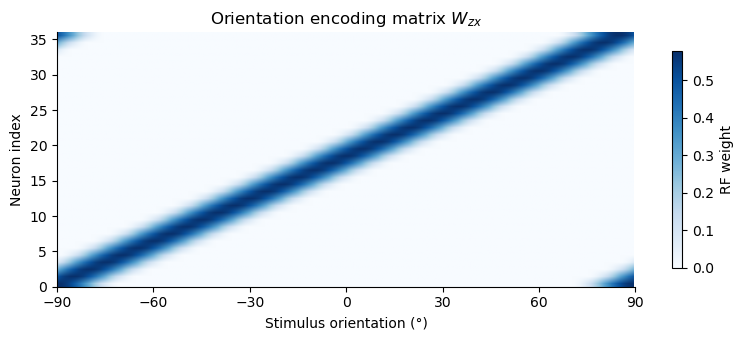

In [7]:
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(Wzx, aspect='auto', origin='lower',
               extent=[theta[0]*180/np.pi, theta[-1]*180/np.pi, 0, Ntheta],
               cmap='Blues', interpolation='bilinear', vmin=0)
fig.colorbar(im, ax=ax, shrink=0.85, label='RF weight')
ax.set_xlabel('Stimulus orientation (°)')
ax.set_ylabel('Neuron index')
ax.set_title('Orientation encoding matrix $W_{zx}$')
ax.set_xticks(np.arange(-90, 91, 30))
plt.tight_layout()
plt.show()

### 1.1 Contrast-Response Curves

In [8]:
contrasts = np.logspace(np.log10(0.01), np.log10(1), 100)
attn_gain = 2
N_index = Ntheta // 2

duration = 1000  # ms
dt = 1e-2

stim_onset = 200
stim_offset = 800

window_start = int(stim_onset / dt)
window_end = int(stim_offset / dt)

In [9]:
wind_attn_no_gain = windowed_attention(Ntheta, onset=stim_onset, offset=stim_offset, gain=1.0)
wind_attn_glob_gain = windowed_attention(Ntheta, onset=stim_onset, offset=stim_offset, gain=attn_gain)
ori_attn_pref = orientation_attention(Ntheta, neuron_index=N_index, onset=stim_onset, offset=stim_offset, gain=attn_gain)

attn_arr = [wind_attn_no_gain, wind_attn_glob_gain, ori_attn_pref]

In [10]:
angle_pref = 0
angle_nonpref = angle_pref + 5 
angle_mask = -90 
mask_contrast = 0.25

results = {}

for i, attn in enumerate(attn_arr):
    results[i] = {"pref": [], "nonpref": [], "pref_plus_mask": []}

    for c in contrasts:
        stim_pref = orientation_stimulus(
            onset=stim_onset,
            offset=stim_offset,
            angle_deg=angle_pref,
            amplitude=c,
            theta_axis=theta_axis,
        )

        t, v = model.simulate(
            stimulus_fn=stim_pref,
            attention_fn=attn,
            t_span=(0, duration),
            dt=dt
        )
        results[i]["pref"].append(np.mean(v[N_index, window_start:window_end] ** 2))

        stim_nonpref = orientation_stimulus(
            onset=stim_onset, offset=stim_offset,
            angle_deg=angle_nonpref, amplitude=c,
            theta_axis=theta_axis,
        )

        t, v = model.simulate(
            stimulus_fn=stim_nonpref,
            attention_fn=attn,
            t_span=(0, duration),
            dt=dt
        )
        results[i]["nonpref"].append(np.mean(v[N_index, window_start:window_end] ** 2))

        stim_mask = orientation_stimulus(
            onset=stim_onset,
            offset=stim_offset,
            angle_deg=angle_mask,
            amplitude=mask_contrast,
            theta_axis=theta_axis, 
        )

        stim_pref_plus_mask = (lambda s1=stim_pref, s2=stim_mask: (lambda tt: s1(tt) + s2(tt)))()

        t, v = model.simulate(stimulus_fn=stim_pref_plus_mask,
                              attention_fn=attn,
                              t_span=(0, duration),
                              dt=dt
                            )
        results[i]["pref_plus_mask"].append(np.mean(v[N_index, window_start:window_end] ** 2))


KeyboardInterrupt: 

Mean squared membrane potential during the stimulus window serves as a proxy for firing rate. Each curve below averages the sustained response of the target unit.

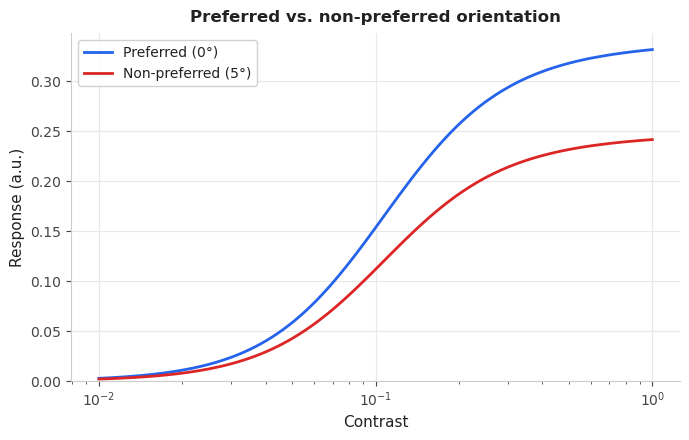

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(contrasts, results[0]["pref"], color=C_PREF, lw=2, label=f'Preferred ({angle_pref}°)')
ax.plot(contrasts, results[0]["nonpref"], color=C_NONP, lw=2, label=f'Non-preferred ({angle_nonpref}°)')
ax.set_xscale('log')
ax.set_xlabel('Contrast')
ax.set_ylabel('Response (a.u.)')
ax.set_title('Preferred vs. non-preferred orientation')
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

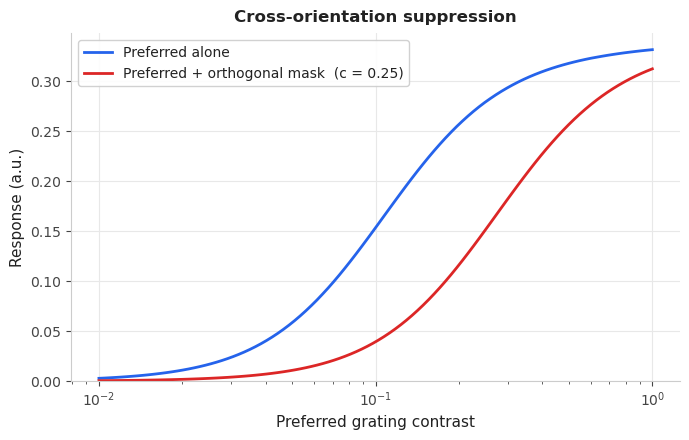

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(contrasts, results[0]["pref"], color=C_PREF, lw=2, label='Preferred alone')
ax.plot(contrasts, results[0]["pref_plus_mask"], color=C_NONP, lw=2,
        label=f'Preferred + orthogonal mask (c={mask_contrast})')
ax.set_xscale('log')
ax.set_xlabel('Preferred grating contrast')
ax.set_ylabel('Response (a.u.)')
ax.set_title('Cross-orientation suppression')
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

/var/folders/ry/fy29vzdj4g93lnnzkp4k7p_h0000gn/T/ipykernel_10690/1394177286.py:30: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


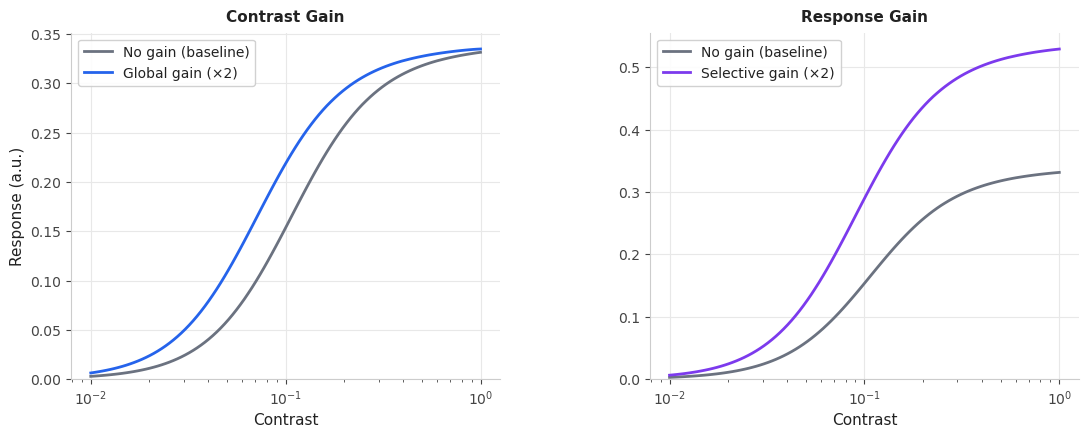

In [ ]:
fig, (ax_l, ax_r) = plt.subplots(1, 2, figsize=(11, 4), gridspec_kw=dict(wspace=0.35))

for ax in (ax_l, ax_r):
    ax.plot(contrasts, results[0]["pref"], color=C_BASE, lw=2, label='Baseline')

ax_l.plot(contrasts, results[1]["pref"], color=C_GLOBAL, lw=2, label=f'Global gain (×{attn_gain})')
ax_l.set_xscale('log')
ax_l.set_xlabel('Contrast')
ax_l.set_ylabel('Response (a.u.)')
ax_l.set_title('Contrast Gain')
ax_l.set_ylim(bottom=0)
ax_l.legend()

ax_r.plot(contrasts, results[2]["pref"], color=C_SELECT, lw=2, label=f'Selective gain (×{attn_gain})')
ax_r.set_xscale('log')
ax_r.set_xlabel('Contrast')
ax_r.set_title('Response Gain')
ax_r.set_ylim(bottom=0)
ax_r.legend()

plt.tight_layout()
plt.show()

### 1.2 Tuning curves effects

In [ ]:
attn_gain = 2 

wind_attn_no_gain = windowed_attention(Ntheta, onset=stim_onset, offset=stim_offset, gain=1.0)
wind_attn_glob_gain = windowed_attention(Ntheta, onset=stim_onset, offset=stim_offset, gain=attn_gain)
ori_attn_pref = orientation_attention(Ntheta, neuron_index=N_index, onset=stim_onset, offset=stim_offset, gain=attn_gain)

attn_arr = [wind_attn_no_gain, wind_attn_glob_gain, ori_attn_pref]
orientations = np.linspace(-90, 90, 100, endpoint=False)

for i, attn in enumerate(attn_arr):

    results[i] = []

    for orient in orientations:
        stim = orientation_stimulus(
            onset=stim_onset,
            offset=stim_offset,
            angle_deg=orient,
            amplitude=0.5,
            theta_axis=theta_axis,
        )

        t, v = model.simulate(
            stimulus_fn=stim,
            attention_fn=attn,
            t_span=(0, duration),
            dt=dt
        )
        results[i].append(np.mean(v[N_index, window_start:window_end] ** 2))

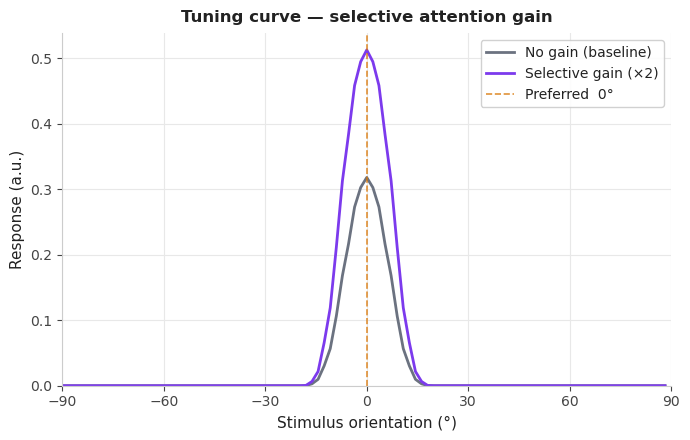

In [ ]:
fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(orientations, results[0], color=C_BASE, lw=2, label='Baseline')
ax.plot(orientations, results[2], color=C_SELECT, lw=2, label=f'Selective gain (×{attn_gain})')
ax.axvline(pref_deg, color=C_TARGET, lw=1, ls='--', alpha=0.7, label=f'Preferred {pref_deg:.0f}°')
ax.set_xlabel('Stimulus orientation (°)')
ax.set_ylabel('Response (a.u.)')
ax.set_title('Tuning curve — selective attention')
ax.set_xlim(-90, 90)
ax.set_xticks(np.arange(-90, 91, 30))
ax.set_ylim(bottom=0)
ax.legend()
plt.tight_layout()
plt.show()

In [ ]:
attn_gain=1.1

wind_attn_no_gain = windowed_attention(Ntheta, onset=stim_onset, offset=stim_offset, gain=1.0)
wind_attn_glob_gain = windowed_attention(Ntheta, onset=stim_onset, offset=stim_offset, gain=1.2)
ori_attn_pref = orientation_attention(Ntheta, neuron_index=N_index, onset=stim_onset, offset=stim_offset, gain=attn_gain)

attn_arr = [wind_attn_no_gain, wind_attn_glob_gain, ori_attn_pref]
results_no_gain = []
results_glob_gain = []
results_selected_gain = []
for i in range(100):

    stim = grating_plus_noise_stimulus(
                onset=stim_onset,
                offset=stim_offset,
                angle_deg=0,
                contThresh=0.25,
                theta_axis=MM.theta_deg,
                noise_contrast=0.2,
                target_present=True, seed=300+i,
                )

    _, v_no_fain = model.simulate(
                stimulus_fn=stim,
                attention_fn=wind_attn_no_gain,
                t_span=(0, duration),
                dt=dt
            )

    _, v_glob_gain = model.simulate(
                stimulus_fn=stim,
                attention_fn=wind_attn_glob_gain,
                t_span=(0, duration),
                dt=dt
            )
    
    _, v_sel_gain = model.simulate(
                stimulus_fn=stim,
                attention_fn=ori_attn_pref,
                t_span=(0, duration),
                dt=dt)

    results_no_gain.append(np.mean(v_no_fain[:Ntheta, window_start:window_end] ** 2, axis=1))
    results_glob_gain.append(np.mean(v_glob_gain[:Ntheta, window_start:window_end] ** 2, axis=1))
    results_selected_gain.append(np.mean(v_sel_gain[:Ntheta, window_start:window_end] ** 2, axis=1))


/opt/homebrew/Caskroom/miniforge/base/envs/organics/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:63: RuntimeWarning: overflow encountered in dot
  dy = np.dot(K[:s].T, a[:s]) * h
/Users/andre/Documents/Masters/Internships/Code_repos/ORGaNICs/organics_standalone/organics_toolbox/core/organics_dynamics.py:38: RuntimeWarning: invalid value encountered in add
  da = (-a + sqrt_u + a * sqrt_u) / params.tau_a
/opt/homebrew/Caskroom/miniforge/base/envs/organics/lib/python3.14/site-packages/scipy/integrate/_ivp/rk.py:179: RuntimeWarning: overflow encountered in dot
  Q = self.K.T.dot(self.P)


## 2. Spatial Validation

In [ ]:
FOV_deg = (-30, 30)
overlap_theta = 2
overlap_xi = 2
Ntheta = 12

MM = MakeMatrices(
    Ntheta=Ntheta,
    overlap_theta=overlap_theta,
    overlap_xi=overlap_xi,
    FOV_deg=FOV_deg,
    apply_cortical_magnification=True,
)

theta_deg = MM.theta_deg
theta_preferred = MM.theta_preferred
thetaRFs = MM.make_orientation_rfs()

xiRFs = MM.make_spatial_rfs()
Wxi = MM.make_spatial_norm_weights()


### Runing testing script
- Strong suppressions when amplitude is 1 for the central neurons.

In [ ]:
FOV_deg = (-60, 60)
duration = 1000
dt = 0.1
stim_onset = 200
stim_offset = 800

center_degs = [-10, 0, 10]
size_deg = 10
amp = 0.5

In [ ]:
MM = MakeMatrices(
    apply_cortical_magnification=True,
)

xiRFs = MM.make_spatial_rfs()
Wxi = MM.make_spatial_norm_weights()
xi_deg = MM.xi_deg
Nxi = MM.Nxi

The spatial encoding matrix $W_{\xi x}$ maps retinal positions to neural units with cortical magnification: units near the fovea have narrower, denser receptive fields than peripheral ones.

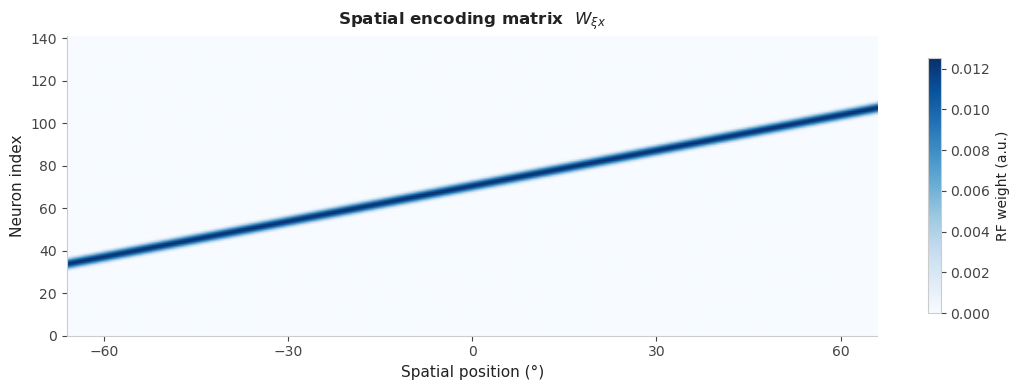

In [ ]:
fig, ax = plt.subplots(figsize=(8, 3.5))
im = ax.imshow(xiRFs, aspect='auto', origin='lower',
               extent=[xi_deg[0], xi_deg[-1], 0, Nxi],
               cmap='Blues', interpolation='bilinear', vmin=0)
fig.colorbar(im, ax=ax, shrink=0.85, label='RF weight')
ax.set_xlim(1.1 * FOV_deg[0], 1.1 * FOV_deg[1])
ax.set_xticks([FOV_deg[0], -30, 0, 30, FOV_deg[1]])
ax.set_xlabel('Spatial position (°)')
ax.set_ylabel('Neuron index')
ax.set_title('Spatial encoding matrix $W_{\\xi x}$')
plt.tight_layout()
plt.show()

In [ ]:
model = Population1DModel(
    n_units=Nxi,
    Wzx=xiRFs,
    Wnorm=Wxi,
    Wyy=np.eye(Nxi),
)
attn_fn = windowed_attention(Nxi, 0, 1e9, gain=1)

results = {}
all_Y_win = []
all_Y = []
for center in center_degs:

    results[center] = []

    stim_fn = spatial_stimulus(
        onset=100,
        offset=500,
        center_deg=center,
        size_deg=size_deg,
        amplitude=amp,
        xi_axis=MM.xi_deg
    )

    t, v = model.simulate(
        stimulus_fn=stim_fn,
        attention_fn=attn_fn,
        t_span=(0.0, 600),
        dt=dt
    )
    y = np.maximum(v[:Nxi, :], 0) ** 2   # firing rate = relu(v)^2
    all_Y.append(y)

    win = (t >= stim_onset) & (t <= stim_offset)
    all_Y_win.append(y[:, win])

In [ ]:
Y_both = np.vstack(all_Y) 
t_win = t[win]

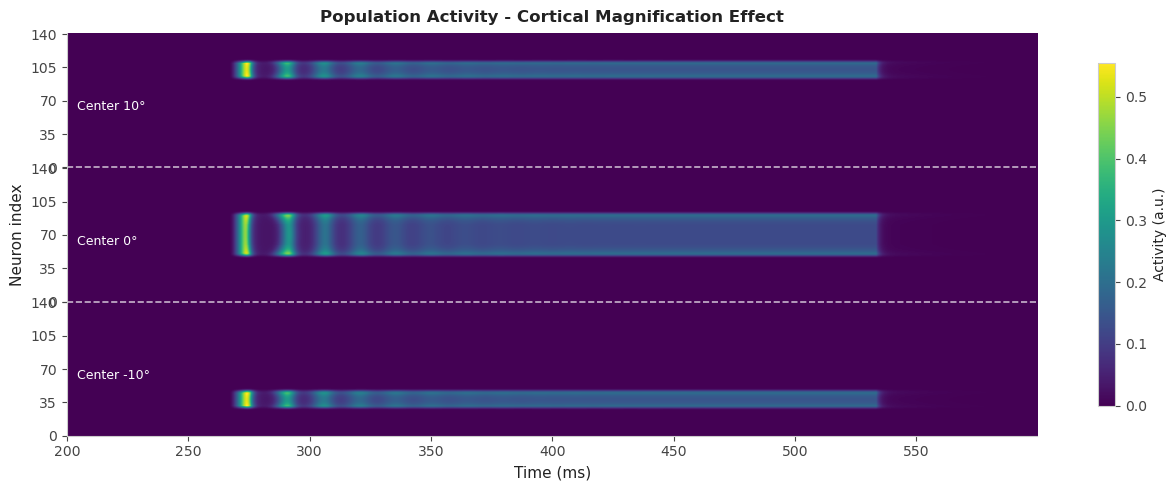

In [ ]:
import matplotlib.ticker as mticker

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(Y_both, aspect='auto', origin='lower',
               extent=[t_win[0], t_win[-1], 0, Y_both.shape[0]],
               cmap='viridis', interpolation='nearest')
fig.colorbar(im, ax=ax, shrink=0.85, label='Activity (a.u.)')
for i in range(len(center_degs)):
    if i < len(center_degs) - 1:
        ax.axhline(Nxi * (i + 1), color='white', lw=1, ls='--', alpha=0.6)
    ax.text(t_win[0] + (t_win[-1] - t_win[0]) * 0.01, Nxi * i + Nxi * 0.45,
            f'Center {center_degs[i]}°', color='white', fontsize=9, va='center')
step = max(1, Nxi // 4)
ax.set_yticks([Nxi * i + local for i in range(len(center_degs)) for local in range(0, Nxi, step)])
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda y, _: str(int(round(y)) % Nxi)))
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Neuron index')
ax.set_title('Population activity — cortical magnification')
plt.tight_layout()
plt.show()

## 3. 2D Validation

The 2D model jointly encodes orientation and spatial position. Each unit is indexed by an (orientation, space) pair; divisive normalization pools across both dimensions, so competing stimuli suppress each other.

In [ ]:
stim_onset = 200
stim_offset = 800
amp = 0.5

ori_deg = 0
center_right = +7.5
center_left = -7.5
size_deg = 10

MM = MakeMatrices(Ntheta=12,apply_cortical_magnification=True, FOV_deg=(-30, 30))

thetaRFs = MM.make_orientation_rfs() 
xiRFs = MM.make_spatial_rfs()

MM.make_orientation_norm_weights()
MM.make_spatial_norm_weights()
Wnorm = MM.combine_normalization_weights(scale_spatial=1.0)  # (N, N)

Wyy = MM.make_recurrence_matrix("2D_identity")  

Ntheta = MM.Ntheta
Nxi = MM.Nxi
N = Ntheta * Nxi


model2d = Population2DModel(
    n_ori=Ntheta,
    n_space=Nxi,
    Wyy=Wyy,
    Wnorm=Wnorm,
)

In [ ]:
# Right: clean 0°
x_theta_right_fn = orientation_stimulus(
    onset=stim_onset, offset=stim_offset,
    angle_deg=0,
    amplitude=1.0,
    theta_axis=MM.theta_deg
)

# Left: mixture of random orientations

x_theta_left_fn = grating_plus_noise_stimulus(
    onset=stim_onset,
    offset=stim_offset,
    angle_deg=0,
    contThresh=0,
    theta_axis=MM.theta_deg, 
    noise_contrast=0.2,
    target_present=False,
    seed=1)

x_xi_right_fn = spatial_stimulus(
    onset=stim_onset, offset=stim_offset,
    center_deg=center_right, size_deg=size_deg,
    amplitude=1.0, xi_axis=MM.xi_deg
)

x_xi_left_fn = spatial_stimulus(
    onset=stim_onset, offset=stim_offset,
    center_deg=center_left, size_deg=size_deg,
    amplitude=1.0, xi_axis=MM.xi_deg
)

amp_right = 0.5
amp_left = 0.5

stim_fn_2d = lambda t: (
    joint_encode(x_theta_right_fn(t), x_xi_right_fn(t), thetaRFs, xiRFs) +
    joint_encode(x_theta_left_fn(t),  x_xi_left_fn(t),  thetaRFs, xiRFs)
)

t, v = model2d.simulate(
    stimulus_fn=stim_fn_2d,
    attention_fn=windowed_attention(N, 0, 1e9, gain=1.0),
    t_span=(0.0, duration),
    dt=dt
)

y = v[:N, :]**2
Y = y.reshape(Ntheta, Nxi, -1)   # C-order: index = i*Nxi + j (matches dynamics)


In [ ]:
y = v[:N, :]**2
Y = y.reshape(Ntheta, Nxi, -1)   # C-order: index = i*Nxi + j (matches dynamics)
print(y.shape, Y.shape)

(1332, 10000) (12, 111, 10000)


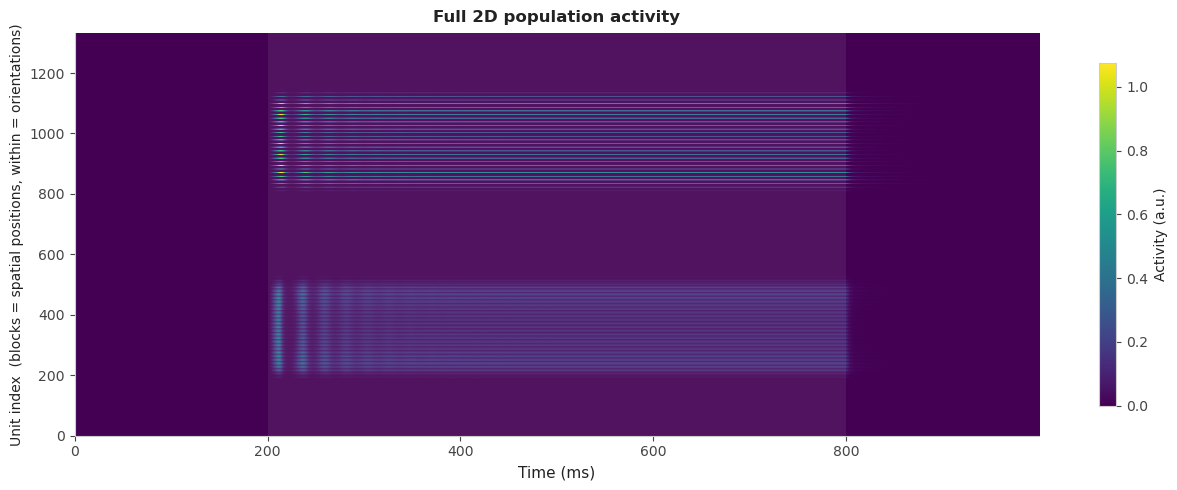

In [ ]:
y_spatial = y.reshape(Ntheta, Nxi, -1).transpose(1, 0, 2).reshape(N, -1)

fig, ax = plt.subplots(figsize=(11, 4))
im = ax.imshow(y_spatial, aspect='auto', origin='lower',
               extent=[t[0], t[-1], 0, N],
               cmap='viridis', interpolation='nearest')
fig.colorbar(im, ax=ax, shrink=0.85, label='Activity (a.u.)')
ax.axvspan(stim_onset, stim_offset, color='white', alpha=0.07, lw=0)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Unit index (blocks = space, within = orientation)')
ax.set_title('Full 2D population activity')
plt.tight_layout()
plt.show()

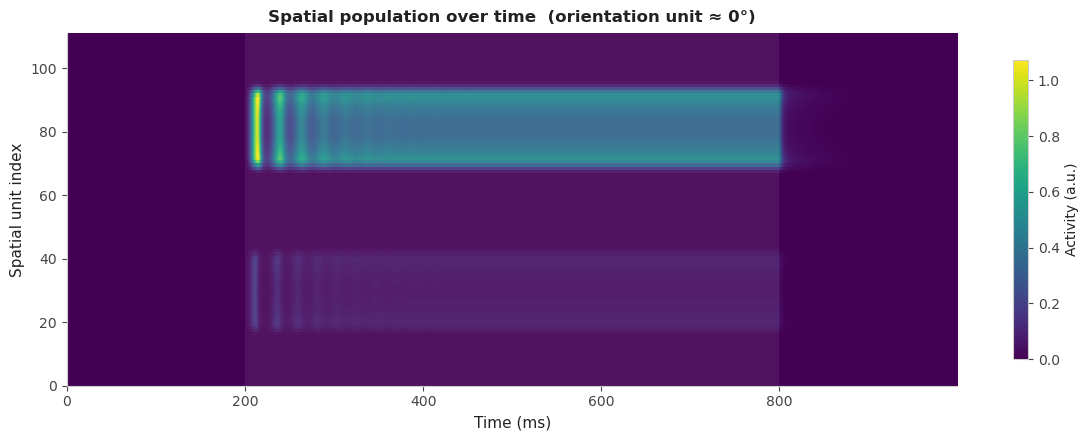

In [ ]:
ori_idx = np.argmin(np.abs(MM.theta_preferred_deg - ori_deg))

fig, ax = plt.subplots(figsize=(10, 3.5))
im = ax.imshow(Y[ori_idx, :, :], aspect='auto', origin='lower',
               extent=[t[0], t[-1], 0, Nxi],
               cmap='viridis', interpolation='nearest')
fig.colorbar(im, ax=ax, shrink=0.85, label='Activity (a.u.)')
ax.axvspan(stim_onset, stim_offset, color='white', alpha=0.07, lw=0)
ax.set_xlabel('Time (ms)')
ax.set_ylabel('Spatial unit index')
ax.set_title(f'Spatial population — orientation unit ≈ {ori_deg}°')
plt.tight_layout()
plt.show()

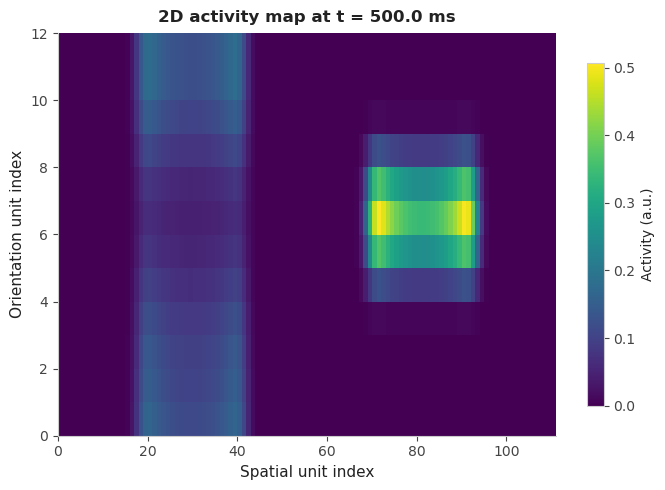

In [ ]:
t0 = 500
k = np.argmin(np.abs(t - t0))

fig, ax = plt.subplots(figsize=(6, 4))
im = ax.imshow(Y[:, :, k], origin='lower', aspect='auto',
               extent=[0, Nxi, 0, Ntheta],
               cmap='viridis')
fig.colorbar(im, ax=ax, shrink=0.85, label='Activity (a.u.)')
ax.set_xlabel('Spatial unit index')
ax.set_ylabel('Orientation unit index')
ax.set_title(f'2D activity snapshot at t = {t[k]:.0f} ms')
plt.tight_layout()
plt.show()